In [ ]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
server= 'V:'
animalID = 'HA11-1R'
date = '2023-05-05'
model_type = 'GLM_3nmf_pre'
  
        

In [3]:
def load_GLM_results_cluster(save_directory, save_string):
    os.chdir(save_directory)
    # Identify all neuron files
    neuron_files = [filename for filename in os.listdir(save_directory) if filename.startswith(save_string)]
    
    # Extract neuron IDs and sort filenames numerically
    neuron_files_sorted = sorted(neuron_files, key=lambda x: int(x.split('_')[-1].split('.')[0]))

    model_output_all = {}  # Create dictionary structure
    for filename in neuron_files_sorted: #can change to specific neurons in here [0:381]
        print(filename)
        neuron_id = filename.split('_')[-1].split('.')[0]  # Extract neuron ID from filename
        neuron_path = os.path.join(save_directory, filename)

        with open(neuron_path, 'rb') as file:
            model_data = pickle.load(file)
        

        for fold, model_output in model_data.items():

            if fold not in model_output_all:
                model_output_all[fold] = {}
            for key, value in model_output.items():
                if key not in model_output_all[fold]:
                    model_output_all[fold][key] = []

                if key in ['B_weights','y_pred','loss_trace','lambda_trace']:
                    model_output_all[fold][key].append(value)
                elif isinstance(value, list):
                    model_output_all[fold][key].extend(value)
                else:
                    model_output_all[fold][key].append(value)

    # Convert lists of arrays to single NumPy arrays where applicable
    for fold, outputs in model_output_all.items():
        for key, value in outputs.items():
            if isinstance(value, list) and len(value) > 0 and isinstance(value[0], np.ndarray):
                if key == 'y_pred':
                    model_output_all[fold][key] = np.stack(value, axis=1)  # Transpose to neurons x frames
                    model_output_all[fold][key] = np.squeeze(model_output_all[fold][key])  # Remove extra dimension
                elif key == 'B_weights':
                    print(f'size beta {np.shape(value)}')
                    model_output_all[fold][key] = np.stack(value, axis=2)  # Transpose to features x neurons
                    model_output_all[fold][key] = np.squeeze(model_output_all[fold][key])  # Remove extra dimension
                else:
                    model_output_all[fold][key] = np.concatenate(value, axis=0)
            else:
                model_output_all[fold][key] = value
    return model_output_all

In [23]:
save_directory_v1 = os.path.join(f'{server}/Connie/ProcessedData/{animalID}/{date}/{model_type}')
        
# Load data from all models

model_output_og = load_GLM_results_cluster(os.path.join(save_directory_v1, 'results'), 'poss_model_1_data_cluster_')
model_output_new = load_GLM_results_cluster(os.path.join(save_directory_v1, 'results_updated'), 'poss_model_1_data_cluster_')

# # Calculate the mean across folds for deviance explained
# mean_dev = np.mean([model_output['frac_dev_expl'] for model_output in model_output_og.values()], axis=0)

# results = {}
# results = {
#         'mean_dev': mean_dev,
#         'model_output_all': model_output_all,
#     }
      

poss_model_1_data_cluster_0.pkl
poss_model_1_data_cluster_1.pkl
poss_model_1_data_cluster_2.pkl
poss_model_1_data_cluster_3.pkl
poss_model_1_data_cluster_4.pkl
poss_model_1_data_cluster_5.pkl
poss_model_1_data_cluster_6.pkl
poss_model_1_data_cluster_7.pkl
poss_model_1_data_cluster_8.pkl
poss_model_1_data_cluster_9.pkl
poss_model_1_data_cluster_10.pkl
poss_model_1_data_cluster_11.pkl
poss_model_1_data_cluster_12.pkl
poss_model_1_data_cluster_13.pkl
poss_model_1_data_cluster_14.pkl
poss_model_1_data_cluster_15.pkl
poss_model_1_data_cluster_16.pkl
poss_model_1_data_cluster_17.pkl
poss_model_1_data_cluster_18.pkl
poss_model_1_data_cluster_19.pkl
poss_model_1_data_cluster_20.pkl
poss_model_1_data_cluster_21.pkl
poss_model_1_data_cluster_22.pkl
poss_model_1_data_cluster_23.pkl
poss_model_1_data_cluster_24.pkl
poss_model_1_data_cluster_25.pkl
poss_model_1_data_cluster_26.pkl
poss_model_1_data_cluster_27.pkl
poss_model_1_data_cluster_28.pkl
poss_model_1_data_cluster_29.pkl
poss_model_1_data_cl

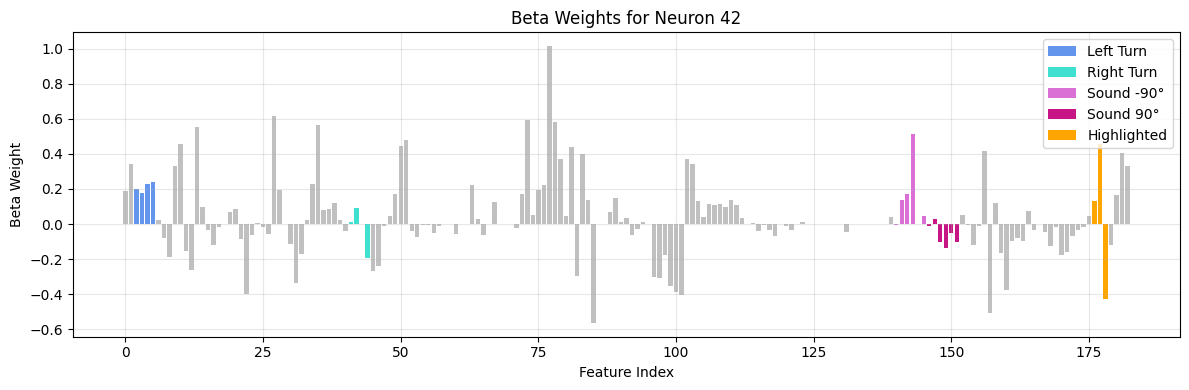

In [19]:
def plot_neuron_betas(model_output_all, neuron_indices, predictor_groups=None):
    """
    Plot beta weights for specified neurons from model output
    
    Parameters:
    - model_output_all: dictionary with fold-wise model outputs
    - neuron_indices: list/array of neuron indices to plot
    - predictor_groups: dictionary defining predictor groups and their indices (optional)
    """
    # Default predictor groups if none provided
    if predictor_groups is None:
        predictor_groups = {
            'left_turn': range(2, 6),
            'right_turn': range(41, 45),
            'sound_-90': range(140, 146),
            'sound_90': range(146, 152),
            'highlighted': range(176, 179)
        }
    
    # Get all fold IDs
    fold_ids = list(model_output_all.keys())
    
    # Create figure
    fig, axes = plt.subplots(len(neuron_indices), 1, 
                            figsize=(12, 4*len(neuron_indices)), 
                            squeeze=False)
    
    for n_idx, neuron in enumerate(neuron_indices):
        # Collect beta weights across folds for this neuron
        betas_across_folds = []
        for fold in fold_ids:
            betas = model_output_all[fold]['B_weights'][:, neuron]
            betas_across_folds.append(betas)
        
        # Calculate mean across folds
        mean_betas = np.mean(np.stack(betas_across_folds, axis=0), axis=0)
        
        # Create color array
        colors = ['silver'] * len(mean_betas)  # default color
        for group, indices in predictor_groups.items():
            if group == 'left_turn':
                color = 'cornflowerblue'
            elif group == 'right_turn':
                color = 'turquoise'
            elif group == 'sound_-90':
                color = 'orchid'
            elif group == 'sound_90':
                color = 'mediumvioletred'
            elif group == 'highlighted':
                color = 'orange'
                
            for idx in indices:
                if idx < len(colors):
                    colors[idx] = color
        
        # Plot
        ax = axes[n_idx, 0]
        ax.bar(range(len(mean_betas)), mean_betas, color=colors)
        ax.set_xlabel('Feature Index')
        ax.set_ylabel('Beta Weight')
        ax.set_title(f'Beta Weights for Neuron {neuron}')
        
        # Add grid for better visibility
        ax.grid(True, alpha=0.3)
        
        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=c, label=l) for l, c in [
                ('Left Turn', 'cornflowerblue'),
                ('Right Turn', 'turquoise'),
                ('Sound -90°', 'orchid'),
                ('Sound 90°', 'mediumvioletred'),
                ('Highlighted', 'orange')
            ]
        ]
        ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    return fig, axes

# Example usage:
neuron_to_plot = [42]  # replace with your neuron index
fig, axes = plot_neuron_betas(model_output_og, neuron_to_plot)
plt.show()

(<Figure size 1200x2000 with 5 Axes>,
 array([[<Axes: title={'center': 'Beta Weights for Neuron 200'}, xlabel='Feature Index', ylabel='Beta Weight'>],
        [<Axes: title={'center': 'Beta Weights for Neuron 201'}, xlabel='Feature Index', ylabel='Beta Weight'>],
        [<Axes: title={'center': 'Beta Weights for Neuron 202'}, xlabel='Feature Index', ylabel='Beta Weight'>],
        [<Axes: title={'center': 'Beta Weights for Neuron 203'}, xlabel='Feature Index', ylabel='Beta Weight'>],
        [<Axes: title={'center': 'Beta Weights for Neuron 204'}, xlabel='Feature Index', ylabel='Beta Weight'>]],
       dtype=object))

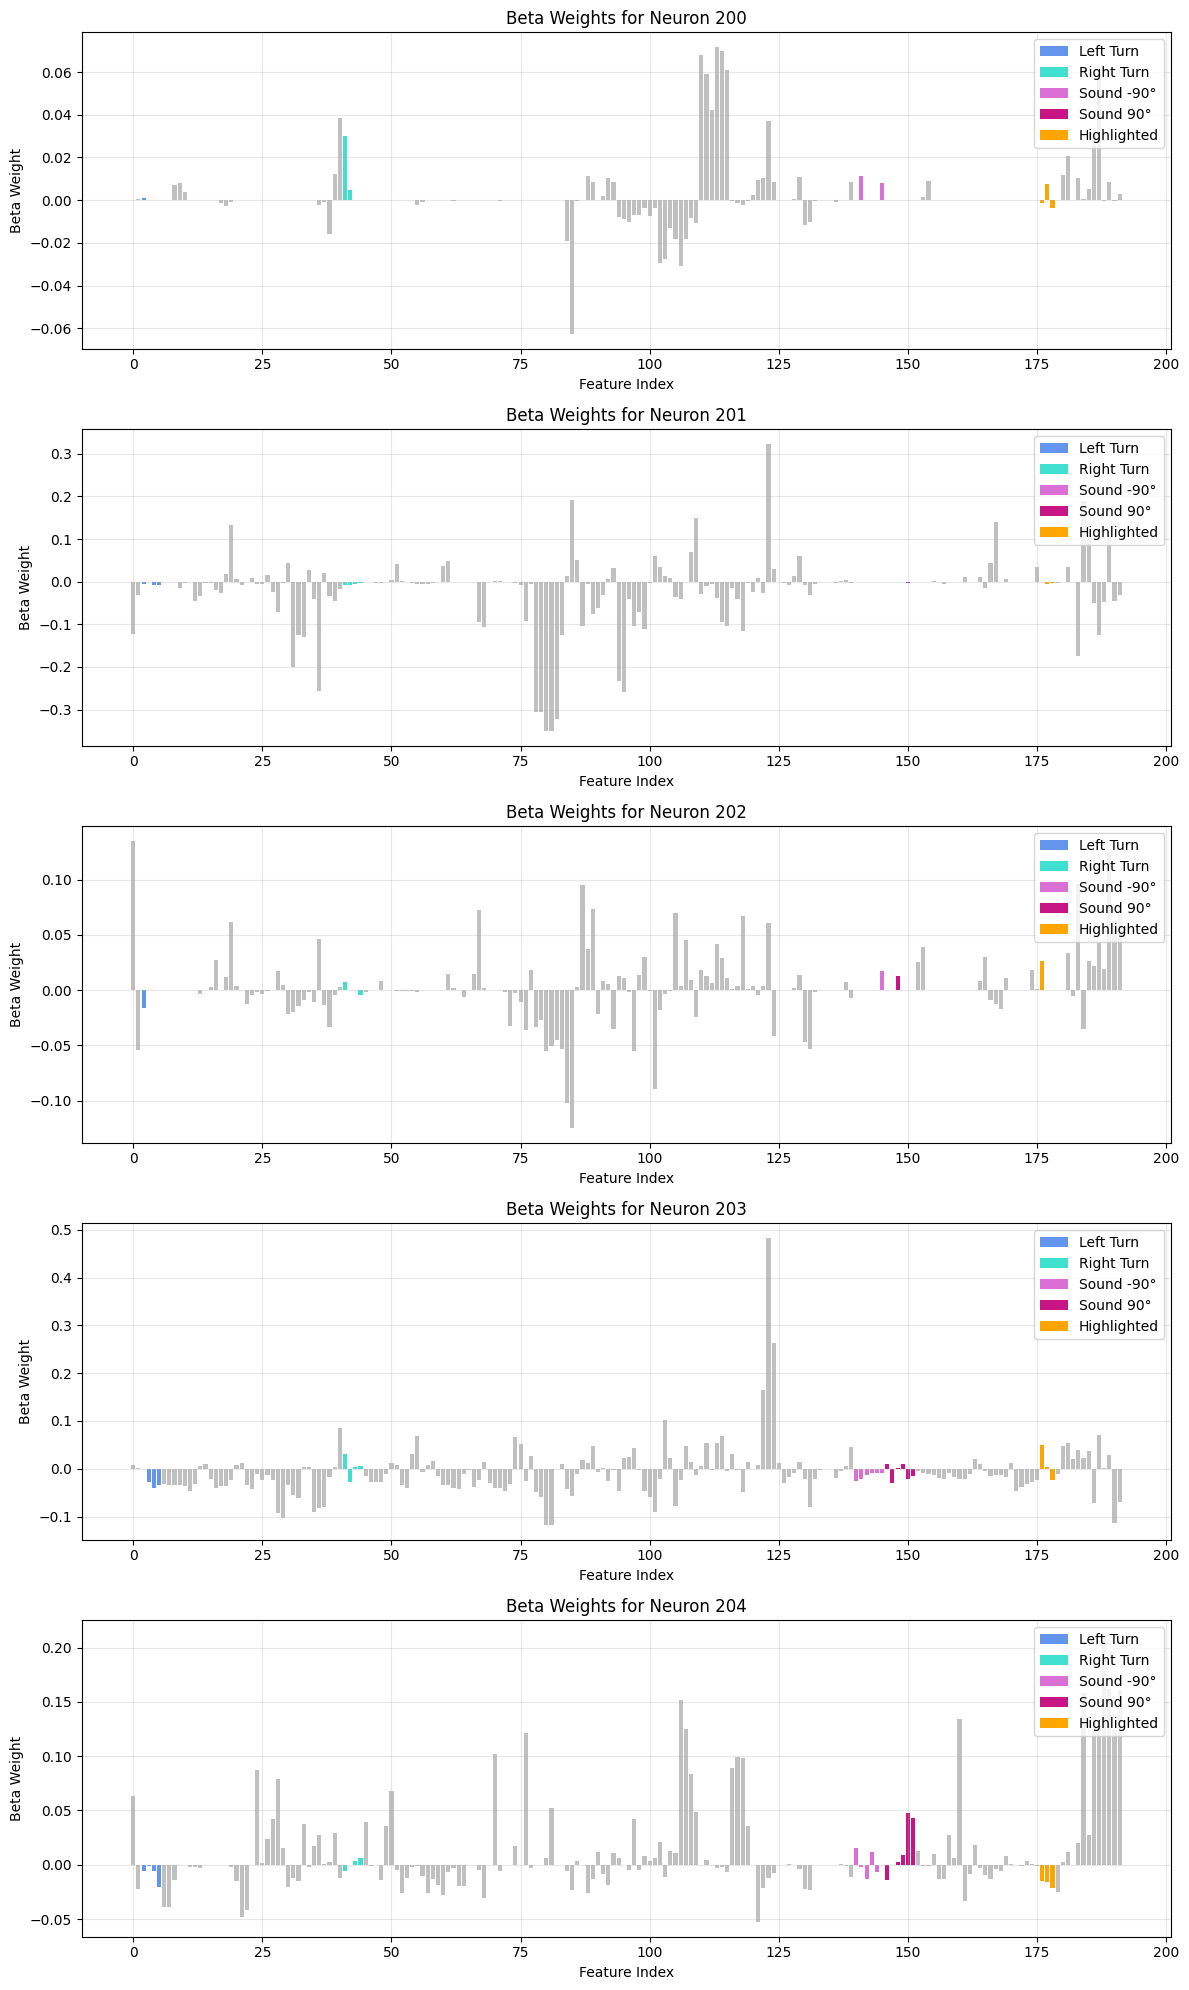

In [29]:
# Example usage:
neuron_idx = [200,201,202,203,204]  # replace with your neuron index
plot_neuron_betas(model_output_new,  neuron_idx)

(<Figure size 1200x3200 with 8 Axes>,
 array([[<Axes: title={'center': 'Beta Weights for Neuron 0'}, xlabel='Feature Index', ylabel='Beta Weight'>],
        [<Axes: title={'center': 'Beta Weights for Neuron 1'}, xlabel='Feature Index', ylabel='Beta Weight'>],
        [<Axes: title={'center': 'Beta Weights for Neuron 2'}, xlabel='Feature Index', ylabel='Beta Weight'>],
        [<Axes: title={'center': 'Beta Weights for Neuron 3'}, xlabel='Feature Index', ylabel='Beta Weight'>],
        [<Axes: title={'center': 'Beta Weights for Neuron 4'}, xlabel='Feature Index', ylabel='Beta Weight'>],
        [<Axes: title={'center': 'Beta Weights for Neuron 5'}, xlabel='Feature Index', ylabel='Beta Weight'>],
        [<Axes: title={'center': 'Beta Weights for Neuron 6'}, xlabel='Feature Index', ylabel='Beta Weight'>],
        [<Axes: title={'center': 'Beta Weights for Neuron 7'}, xlabel='Feature Index', ylabel='Beta Weight'>]],
       dtype=object))

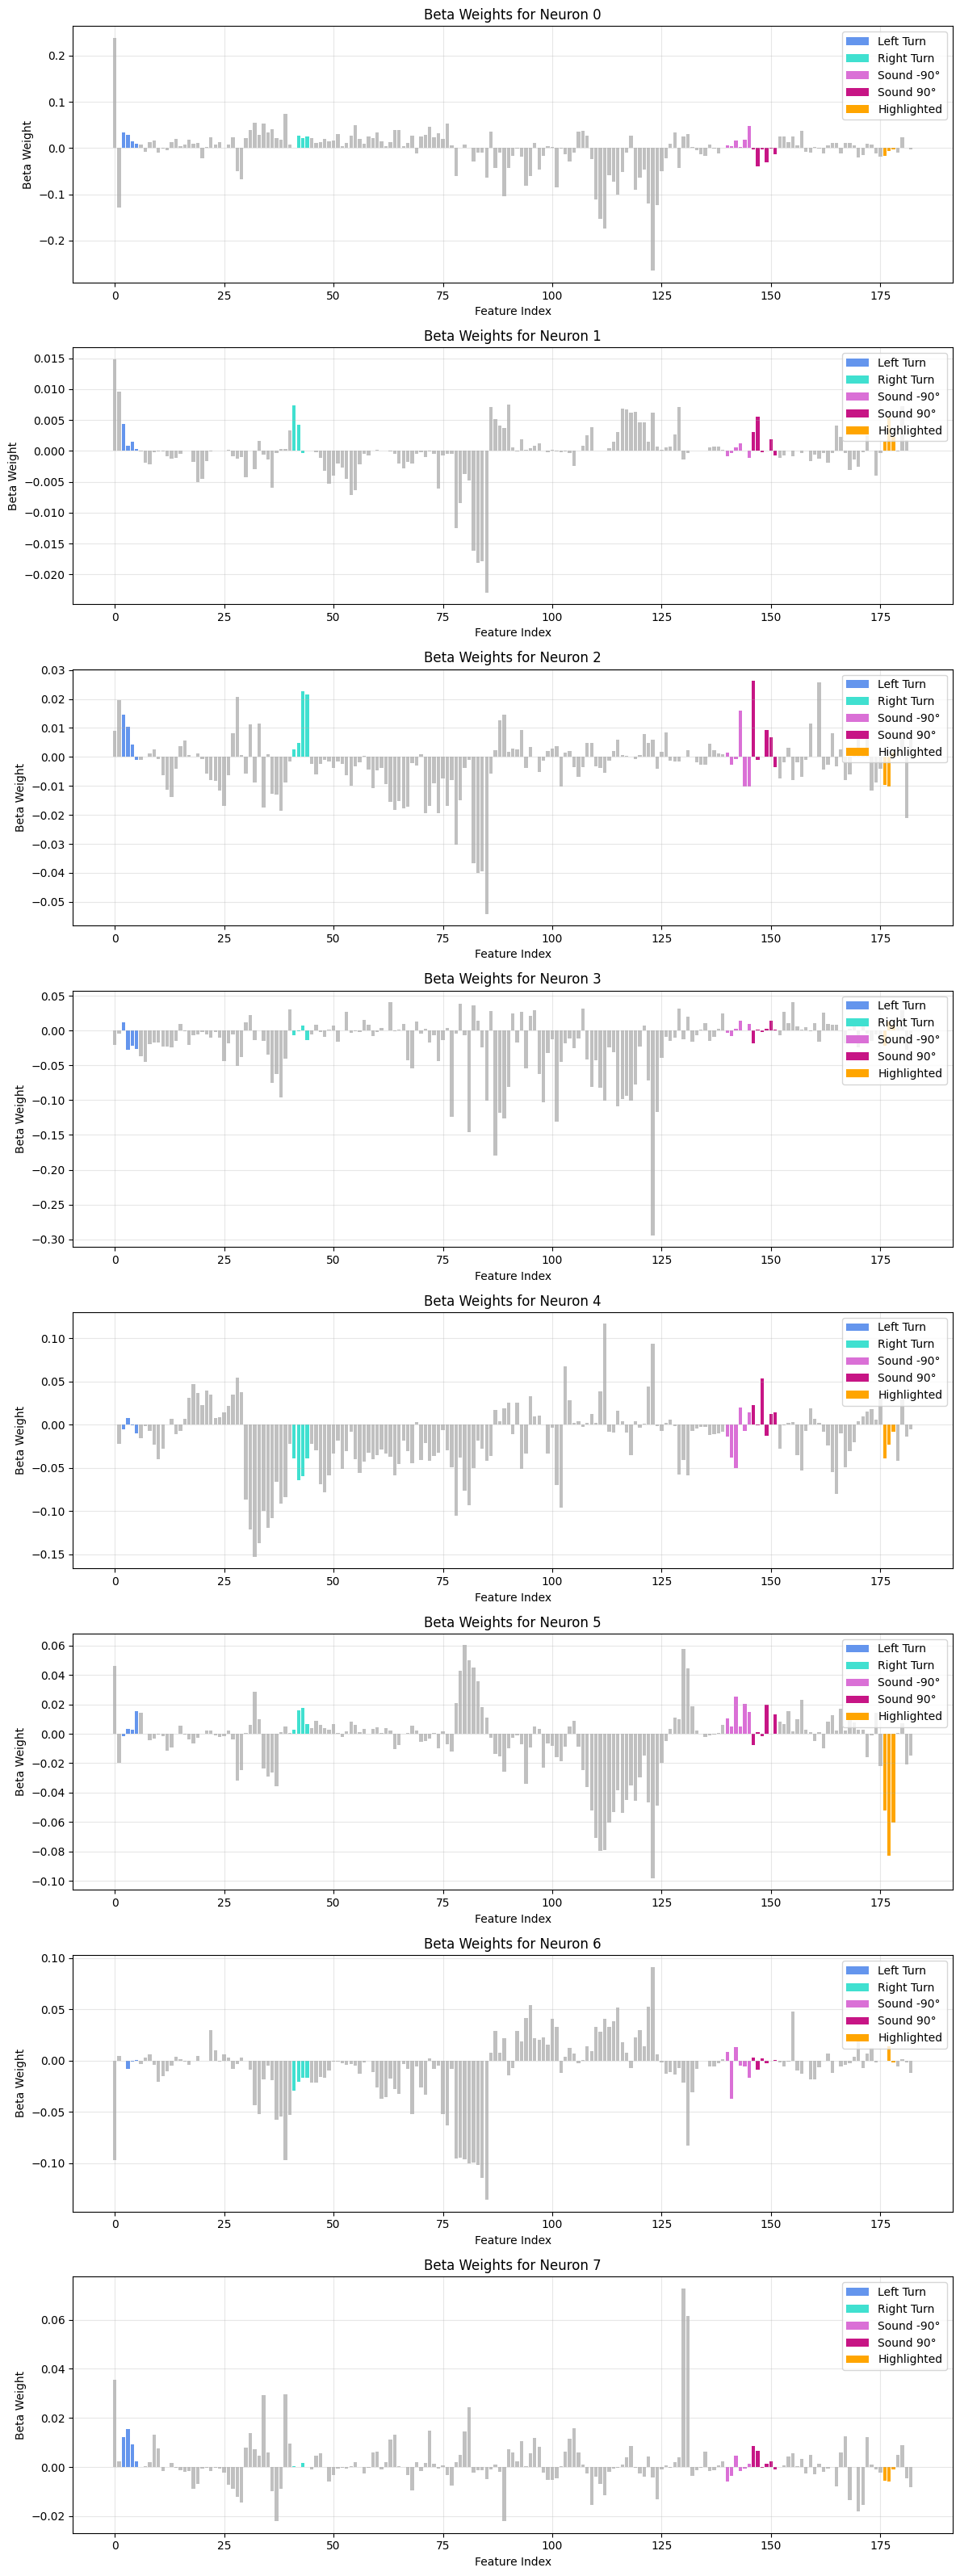

In [21]:
plot_neuron_betas(model_output_new,  neuron_idx)